# CAB420, Clustering, Additional Example 1: How Many Clusters?
Dr Simon Denman (s.denman@qut.edu.au)

## Overview
Let's compare K-Means and a GMM, and look at what happens as we increase the number of clusters. To do this, we're going to use some real data. We'll use a segment of data that shows NY taxi usage. We'll only use one day's data to keep the example from being too slow, and we'll focus only on trips that end at JFK airport, again to reduce the data and make it easy to visualise.

## Too Long; Didn't Read:
* K-means and GMMs need us to specify a number of clusters. However specifying the number of clusters can require prior knowledge of the data, or other exploration.
* We can use a similar method to what we do for regression, and trade off complexity vs accuracy. More clusters will allows us to more accurately reconstruct the data, but at the cost or more parameters.
* We can use Bayesian Information Criterion (BIC) to determine the number of clusters with a GMM, and an approximation of this to determine the same for K-means.
* The BIC and it's approximation often returns quite large numbers of clusters, particularly for K-means. As such for K-means the elbow of the reconstruction curve is a well established heuristic to select the number of clusters. However we may also consider different number of clusters depending on our applications.
* The silhouette score is another well used heuristic that looks at how similar points are to others within their assigned cluster, and how different they are from points in other clusters. This can also be used to help identify an optimal number of clusters for both K-means and GMMs.
* Different methods for estimating K can produce very different results. This is not unusual, as different methods are considering different metrics. Be prepared to try a few different options, and do some data exploration to make your final choice.

In [1]:
import pandas
import numpy
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from scipy.spatial import distance
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

## PART 1: Load the data
We're using just a single day of data. Note that NY taxis come in two flavours:
* Green, which are trips that start outside of Manhattan
* Yellow, which are trips that start within Manhattan

We're going to grab both and combine them. Note that there are slight differences in the table format for the two sets of taxis. To work around this, we'll
* load the two sets
* pull out the columns that we want
* find trips that end at JFK airport
* and grab just those to cluster

In [2]:
green = pandas.read_csv('../data/NYTaxis/2016_Green_Taxi_Trip_Data.csv'); 
yellow = pandas.read_csv('../data/NYTaxis/2016_Yellow_Taxi_Trip_Data.csv');
green = green[['Lpep_dropoff_datetime', 'Dropoff_longitude', 'Dropoff_latitude']]
yellow = yellow[['tpep_pickup_datetime', 'dropoff_longitude', 'dropoff_latitude']]
green = green.rename(columns={'Lpep_dropoff_datetime':'time', 'Dropoff_longitude':'lon', 'Dropoff_latitude':'lat'})
yellow = yellow.rename(columns={'tpep_pickup_datetime':'time', 'dropoff_longitude':'lon', 'dropoff_latitude':'lat'})
taxis = pandas.concat([green, yellow])
print(taxis.shape)
taxis.head()

(409433, 3)


,time,lon,lat
0,01/01/2016 12:00:00 AM,-73.950668,40.811756
1,01/01/2016 12:00:00 AM,-73.999176,40.720001
2,01/01/2016 12:02:10 AM,-73.927147,40.708645
3,01/01/2016 12:40:56 AM,-73.984009,40.743137
4,01/01/2016 12:15:59 AM,-73.866203,40.920212


And then to make it easier to analyse, we'll just look at the dropoff locations around JFK airport.

In [3]:
taxis = taxis[(taxis['lon'] >= -73.805) & (taxis['lon'] <= -73.765) & (taxis['lat'] >= 40.636) & (taxis['lat'] <= 40.656)]
print(taxis.shape)
taxis.head()

(3205, 3)


,time,lon,lat
7219,01/01/2016 01:38:43 AM,-73.783577,40.644234
12536,01/01/2016 02:19:00 AM,-73.782440,40.644226
13253,01/01/2016 02:22:41 AM,-73.782433,40.644253
15727,01/01/2016 02:42:25 AM,-73.776321,40.645702
17101,01/01/2016 03:10:34 AM,-73.782715,40.644169


## PART 2: Clustering
One thing we haven't looked at yet is how many clusters we need. Let's start by getting some intial clustering results for K-means and GMMs with the data.

For each we'll look at 4, 8 and 12 clusters.

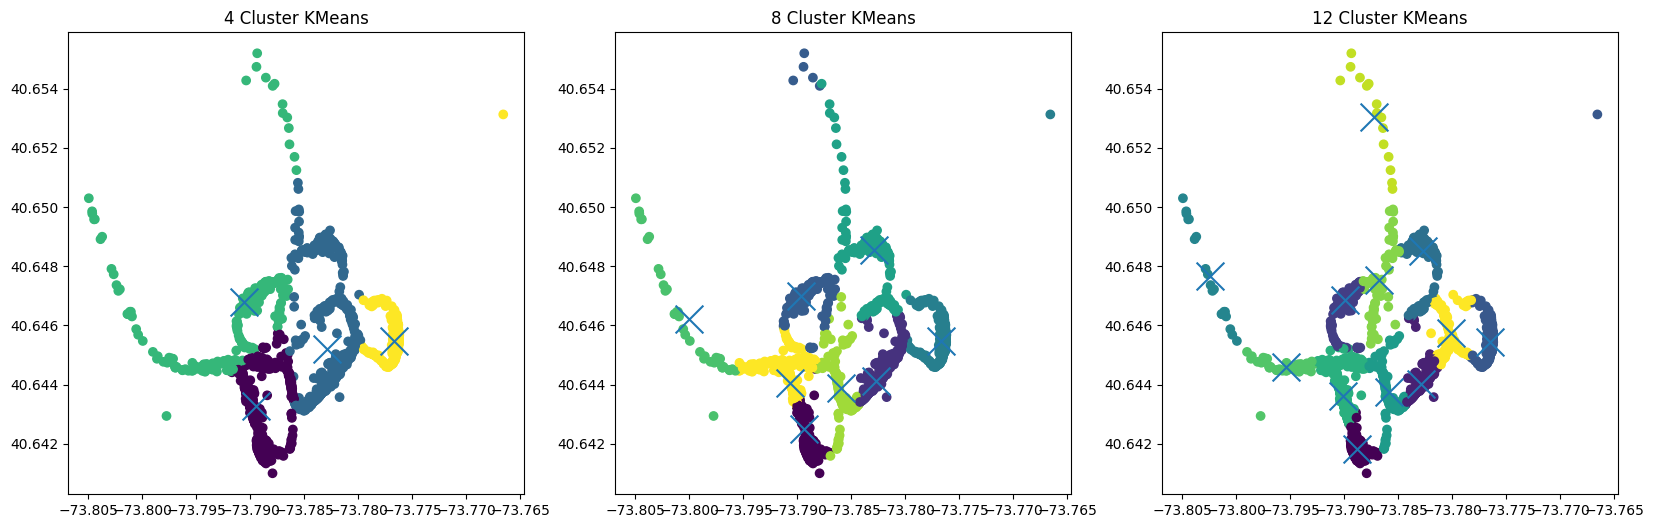

In [4]:
fig = plt.figure(figsize=[20, 6])
ax = fig.add_subplot(1, 3, 1)
kmeans = KMeans(n_clusters=4, random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
ax.scatter(taxis['lon'], taxis['lat'], c=kmeans.labels_);
ax.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', s=400)
ax.set_title('4 Cluster KMeans')

kmeans = KMeans(n_clusters=8, random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
ax = fig.add_subplot(1, 3, 2)
ax.scatter(taxis['lon'], taxis['lat'], c=kmeans.labels_);
ax.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', s=400)
ax.set_title('8 Cluster KMeans')

kmeans = KMeans(n_clusters=12, random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
ax = fig.add_subplot(1, 3, 3)
ax.scatter(taxis['lon'], taxis['lat'], c=kmeans.labels_);
ax.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], marker='x', s=400)
ax.set_title('12 Cluster KMeans');

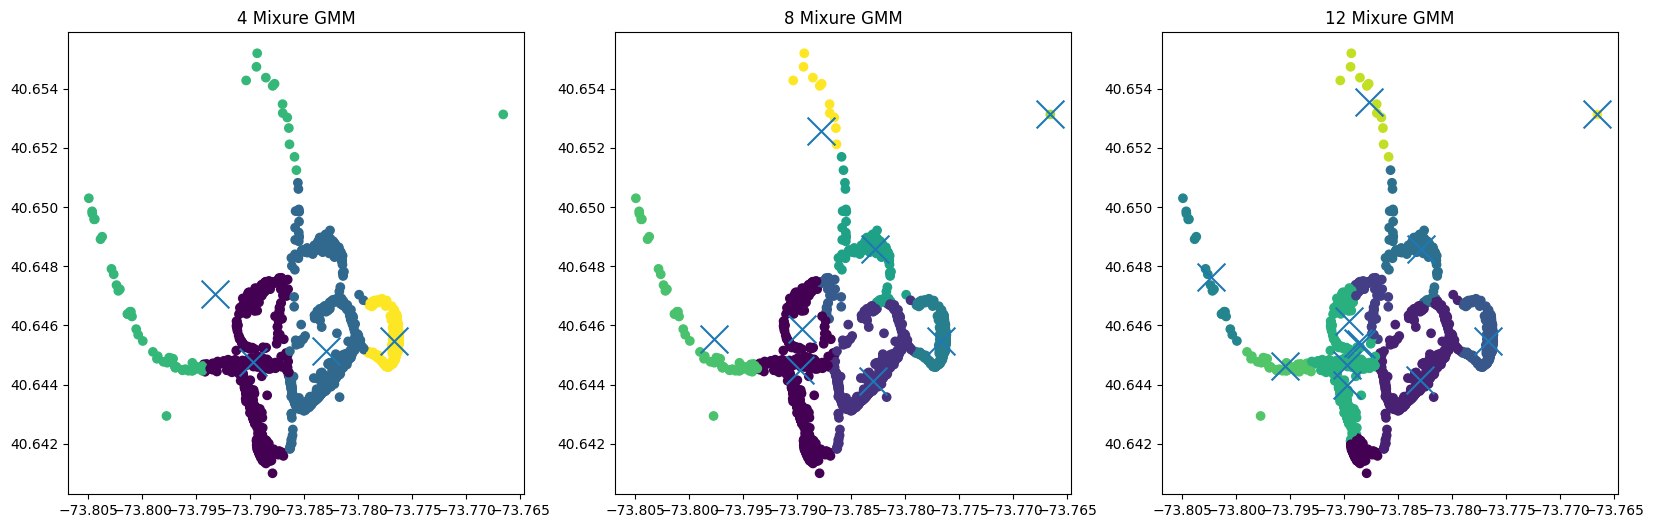

In [5]:
fig = plt.figure(figsize=[20, 6])

gmm = GaussianMixture(4, random_state=4)
gmm.fit(taxis[['lon', 'lat']])
labels = gmm.predict(taxis[['lon', 'lat']])
ax = fig.add_subplot(1, 3, 1)
ax.scatter(taxis['lon'], taxis['lat'], c=labels);
ax.scatter(gmm.means_[:,0], gmm.means_[:,1], marker='x', s=400)
ax.set_title('4 Mixure GMM')

gmm = GaussianMixture(8, random_state=4)
gmm.fit(taxis[['lon', 'lat']])
labels = gmm.predict(taxis[['lon', 'lat']])
ax = fig.add_subplot(1, 3, 2)
ax.scatter(taxis['lon'], taxis['lat'], c=labels);
ax.scatter(gmm.means_[:,0], gmm.means_[:,1], marker='x', s=400)
ax.set_title('8 Mixure GMM')

gmm = GaussianMixture(12, random_state=4)
gmm.fit(taxis[['lon', 'lat']])
labels = gmm.predict(taxis[['lon', 'lat']])
ax = fig.add_subplot(1, 3, 3)
ax.scatter(taxis['lon'], taxis['lat'], c=labels);
ax.scatter(gmm.means_[:,0], gmm.means_[:,1], marker='x', s=400)
ax.set_title('12 Mixure GMM');

We have clustering results. Which one wins? And why?

Often with clustering, there is no single "right" answer, but there are some tools to help guide our selection.

## Part 3: How Many Clusters?

There are a lot of ways to estimate the number of clusters. Some are specific to a single clustering method, some work across multiple methods. Sometimes these methods will produce similar results, othertimes you'll get wild differences. Ultimatley, there is often a need to make a judgement call, and you may need to evaluate different values of K to determine what is best in your case.

### Reconstruction Error Heuristic (K-Means Only)

This approach is often referred to as the "elbow method", and is based on the reconstruction error. For K-means, we can consider the distance between each point and it's assigned cluster as an error:

$C(\underline{x}, \underline{\mu}) = \sum_i ||x_i - \mu_{x_i}||^2$

We can measure this for different values of K, and plot it. Let's do that for a bunch of values of K.

Thanks to the magic of sklearn, we can actually get this number from the inertia attribute which is:
> inertia_ :float
>
>   Sum of squared distances of samples to their closest cluster center.

Note that below I'm going to plot both the reconstruction error as K changes, and the gradient of this line.  

Text(0.5, 1.0, 'Gradient of Reconstruction Error as K Changes (average of 10 trials)')

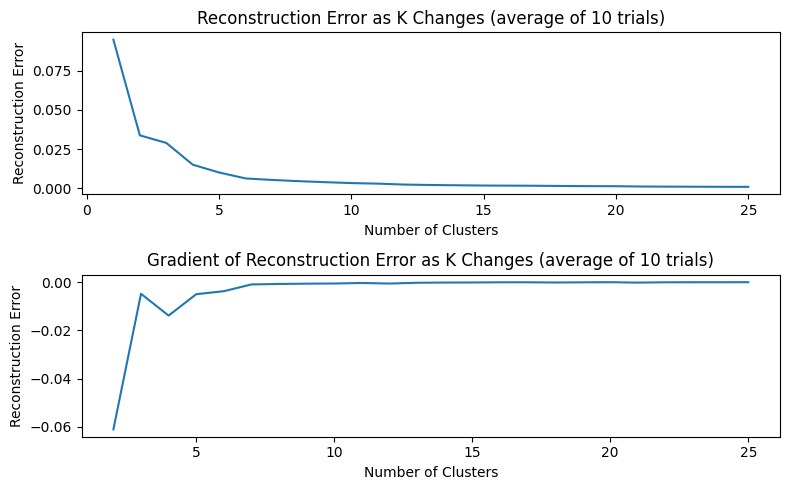

In [6]:
max_k = 25
recon_error = []
for i in range (max_k):
    kmeans = KMeans(n_clusters=(i+1), random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
    recon_error.append(kmeans.inertia_)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), tight_layout=True)
ax[0].plot(range(1, max_k + 1), recon_error)
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Reconstruction Error');
ax[0].set_title('Reconstruction Error as K Changes (average of 10 trials)')

grad = numpy.array(recon_error[1:]) - numpy.array(recon_error[0:-1])
ax[1].plot(range(2, max_k + 1), grad)
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('Reconstruction Error');
ax[1].set_title('Gradient of Reconstruction Error as K Changes (average of 10 trials)')

First up, we see the line is a bit jagged. If this offends you, you can smooth out the plot by running multiple different k-means models with different random states - note though that this can get slow.

Text(0.5, 1.0, 'Gradient of Reconstruction Error as K Changes (average of 10 trials)')

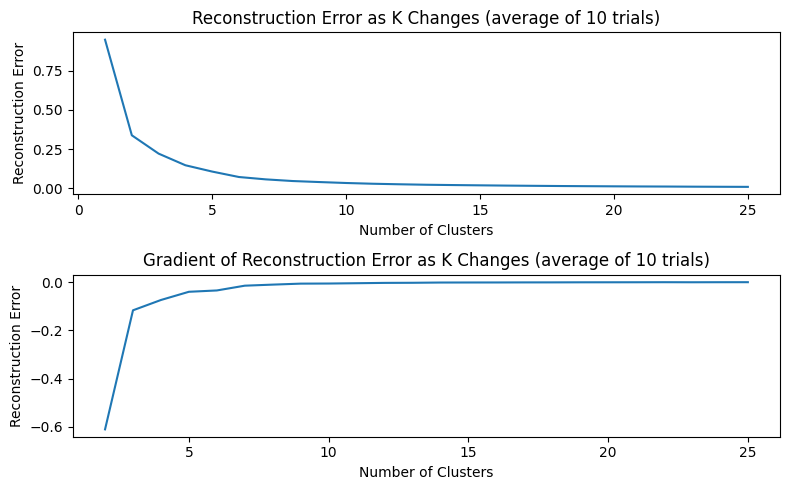

In [7]:
recon_error = []
for i in range (max_k):
    r = 0
    for j in range(10):
        kmeans = KMeans(n_clusters=(i+1), random_state=j, n_init='auto').fit(taxis[['lon', 'lat']])
        r += kmeans.inertia_
    recon_error.append(r)

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), tight_layout=True)
ax[0].plot(range(1, max_k + 1), recon_error)
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Reconstruction Error');
ax[0].set_title('Reconstruction Error as K Changes (average of 10 trials)')

grad = numpy.array(recon_error[1:]) - numpy.array(recon_error[0:-1])
ax[1].plot(range(2, max_k + 1), grad)
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('Reconstruction Error');
ax[1].set_title('Gradient of Reconstruction Error as K Changes (average of 10 trials)')

From either the smoothed or the original single pass plot, we can see our cost quickly drops and converges towards 0. The most clustes we add, the lower this will go. What we are measuring here is the distance between the cluster centres and those points assigned to them. As such, the more cluster cetntres we have, the lower this will go as we will keep creating smaller and smaller groups, each of one which is a bit more tightly packed, until we get to a point where we have as many clusters as points and each point is it's own cluster centre (at which point, we've also clustered absolutely nothing).

With this measure, typically people will select the number of clusters based on the location of the "elbow" in the graph. The idea of an elbow is naturally a little ambiguous, but you could make an argument for anywhere from about 3-6 clusters. Here, plotting the gradient can help as we can see that there's a sharp decrease in the gradient at K=3, and by K=6 the gradient has pretty much become 0. This suggests that fewer than 3 clusters if too few as our error will increase sharply, and more than 6 is too many as this will add very little extra information to the model, so it's effectivley not worth adding another cluster to the data. This is a fairly coarse heuristic, though it is very widely used as a way to determine the number of clusters.

### Information Criterions (Applies to K-Means and GMMs)

We can however add a penalty for model complexity to help overcome the limitations of the "elbow method", while keeping the spirit of this approach. This is based on the idea that we'd like to make our model more complex (i.e. add a mode) only if that mode leads to a substantial improvement. We can see from the above plot, we get a big reduction in error when adding clusters when K is small (i.e. the drop from k=1 to k=2), but when k becomes larger (i.e. k=15) the drop to the next value is quite small. We can modify our cost function as follows:

$I(\underline{x},\underline{\mu}) = m log [ \frac{1}{m} \sum_{i} || x_{i} - \mu_{x_{i}}||^2 ] + k log m$

Note that in our implementation below, we set k to the number of clusters times 3. This comes from the XMeans paper (http://www.aladdin.cs.cmu.edu/papers/pdfs/y2000/xmeans.pdf), in which they calculate the number of free variables for a k-means model with k centroids in d-dimentional space to be k*(d+1), i.e. 3.

Text(0.5, 1.0, 'Gradient of Approximate BIC as K Changes')

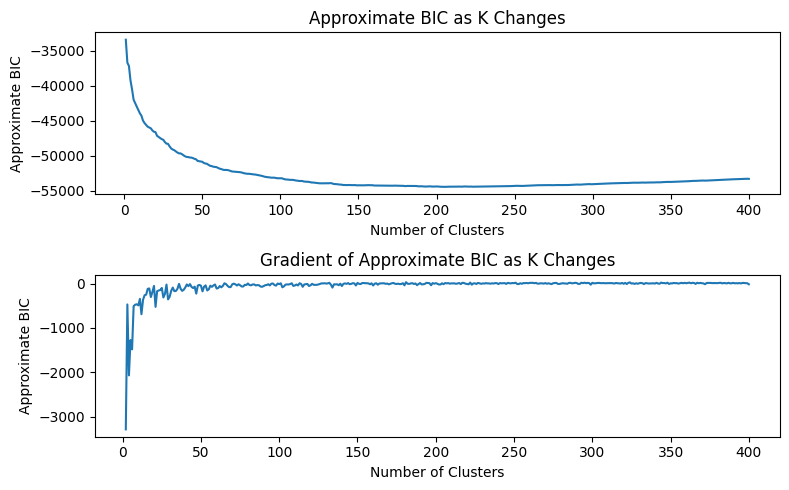

In [8]:
def compute_approximate_bic(kmeans,X):
    
    k = numpy.shape(kmeans.cluster_centers_)[0]*(numpy.shape(kmeans.cluster_centers_)[1] + 1)
    m = len(X)
    
    approx_bic = m*numpy.log(kmeans.inertia_ / m) + k*numpy.log(m)
    return approx_bic    

max_k = 400
bic = []
for i in range (max_k):
    kmeans = KMeans(n_clusters=(i+1), random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
    bic.append(compute_approximate_bic(kmeans, numpy.array(taxis[['lon', 'lat']])))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), tight_layout=True)
ax[0].plot(range(1, max_k + 1), bic)
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('Approximate BIC');
ax[0].set_title('Approximate BIC as K Changes')

grad = numpy.array(bic[1:]) - numpy.array(bic[0:-1])
ax[1].plot(range(2, max_k + 1), grad)
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('Approximate BIC');
ax[1].set_title('Gradient of Approximate BIC as K Changes')

What we see is that our BIC approximation bottoms out around 200. This is still a lot of clusters though, particularly given that we only have a bit over 3,000 data points. Depending on what we are trying to do, this may leave us with a number of clusters which does not suit our task. If for example we are trying to use k-means to cluster our data to help us simplify and visualise things, 200 clusters may still be too many.

For that reason I've also plotted the gradient of this curve, and we can see that beyond about 50 clusters, the gradient is very close to 0. Note that this plot is a bit rough as I've only run one k-means trial per value of k, so we're seeing a lot of noise here, but based on this we could make the call that about 50 clusters is close enough to the minimum as we see very little change beyond that.

Let's apply this to GMMs now, where we can do something similar. 

What we have used above if an approximation of the Bayesian Information Criterion. With a GMM, we can use the actual BIC, and python will compute this for us:

Text(0.5, 1.0, 'Gradient of BIC as K Changes (average of 10 trials)')

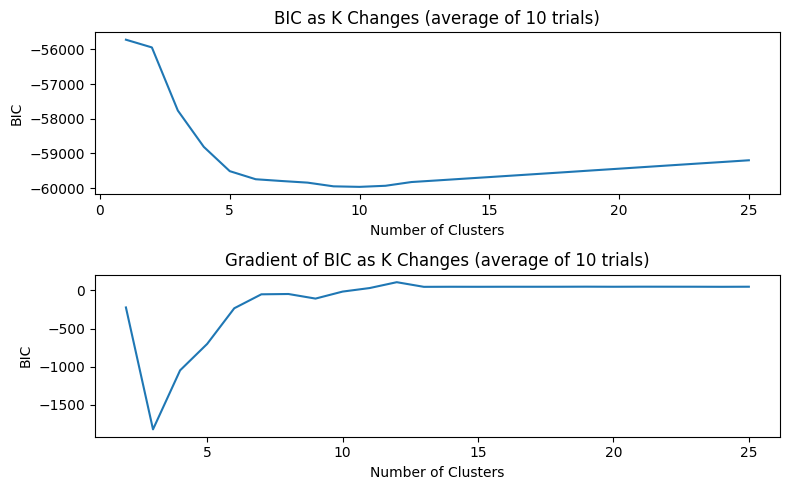

In [9]:
max_k = 25
bics = []
for i in range (max_k):
    b = 0
    for j in range(10):
        gmm = GaussianMixture(i+1, random_state=j)
        gmm.fit(taxis[['lon', 'lat']])
        b += gmm.bic(taxis[['lon', 'lat']])
    bics.append(b / 10.0)
    
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 5), tight_layout=True)
ax[0].plot(range(1, max_k + 1), bics)
ax[0].set_xlabel('Number of Clusters')
ax[0].set_ylabel('BIC');
ax[0].set_title('BIC as K Changes (average of 10 trials)')

grad = numpy.array(bics[1:]) - numpy.array(bics[0:-1])
ax[1].plot(range(2, max_k + 1), grad)
ax[1].set_xlabel('Number of Clusters')
ax[1].set_ylabel('BIC');
ax[1].set_title('Gradient of BIC as K Changes (average of 10 trials)')

Here, I've gone back to averaging 10 iterations to get some smoother plots. We see that out model bottoms around 10, before the BIC starts to increase again. We also see the gradient flatten out quite a bit leading up to K=10, with the gradient becomming close to 0 from about K=7 onwards. Interestingly, this is much smaller than we see with K-means, but we're using a similar metric. Why is this? Quite simply, the GMM has more parameters, we now have not just a cluster centre (as for k-means), but also standard deviations and mixture weights. This means that the penalty for adding modes is bigger as each new clustering is adding substantially more parameters.

However, this doesn't mean that K-means is better because it suggests more clusters. The GMM will also tell us more about the data, we get information on how well a given point matches each component, and we get clusters of much more varied shapes and sizes, so we can potentially fit the data far better with fewer clusters, and we capture uncertainty in decisions which K-means simply wont allow.

### Silhouette Score

For a good clustering result, we'd expect:
* Points to be close to their assigned cluster centres
* Points to be far away from the next closest cluster

Essentially, the clusters should be well separated.

The silhouette coefficient captures this in handy little formula. For a given sample, the silhouette coefficient is

$\frac{b - a}{max(a, b)}$

where $a$ is the distance between a sample and it's assigned cluster, and $b$ is the distance between the sample and the closest cluster other than the one it's assigned to. A value less than 0 suggests that a point has been assigned to the wrong cluster (i.e. there is another cluster closer to the point in question than the one that it's been assigned to). Looking at this value for every single point is pretty impractical, so the silhouette score simply averages this across the data, and overall, higher values indicate better clustering.

For the silhouette score, you will often see some pretty plots drawn that can help capture some information on the quality of the clustering. Let's have a look at a couple of these for k-means with $k=6$ and $k=3$.

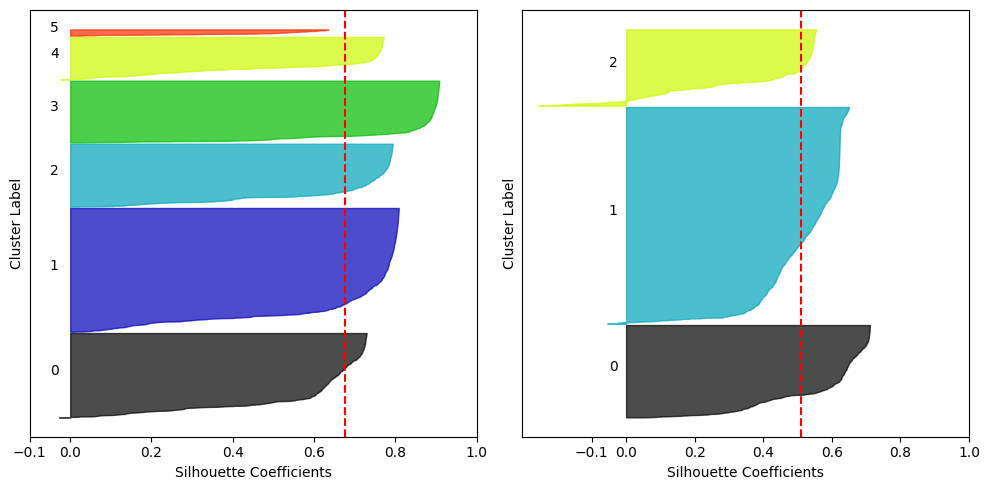

In [10]:
def silhouette_plot(labels, samples, n_clusters, ax):
    # compute average silhouette score
    silhouette_avg = silhouette_score(samples, labels)
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(samples, labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
        ith_cluster_silhouette_values.sort()

        # plot scores for this cluster
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(numpy.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values, facecolor=color, edgecolor=color, alpha=0.7)

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_xlabel("Silhouette Coefficients")
    ax.set_ylabel("Cluster Label")
    
    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    
    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), tight_layout=True)

n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
labels = kmeans.predict(taxis[['lon', 'lat']])
silhouette_plot(labels, taxis[['lon', 'lat']], n_clusters, ax[0])

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=4, n_init='auto').fit(taxis[['lon', 'lat']])
labels = kmeans.predict(taxis[['lon', 'lat']])
silhouette_plot(labels, taxis[['lon', 'lat']], n_clusters, ax[1])

With these plots, each cluster is drawn in a different colour, and the filled contour shows the silhouette coefficient for each point. Coefficients below 0 indicate points that are perhaps misclassified. The red dashed line shows the average silhouette score for the whole dataset.

Considering our $k=6$ model, the vast majority of points have silhouette coefficients above 0. Clusters also seem fairly well sepparated, with in particular $4$ of the clusters having coefficients for most points well above the average. Cluster is perhaps a bit of a concern, but it's also only small. Perhaps a different random initialisation would help improve this. 

For $k=3$, our overall silhouette score is much lower (about 0.5 rather than about 0.7). There are also most points with coefficients below 0, and the plot suggests that separation between clusters is worse overall.

From the above, $k=6$ wins. What this plot doesn't show howver is anything about the distribution of clusters, so if you're trying to understand if one cluster should perhaps be split, or a couple of clusters should be merged, this plot doesn't really tell you anything.

Usually, we won't look at these plots in detail for each possible k. Instead we'll simply compute the silhouette score for a bunch of different k's and draw a graph. 

Text(0.5, 1.0, 'Silhouette Score as K Changes (average of 10 trials)')

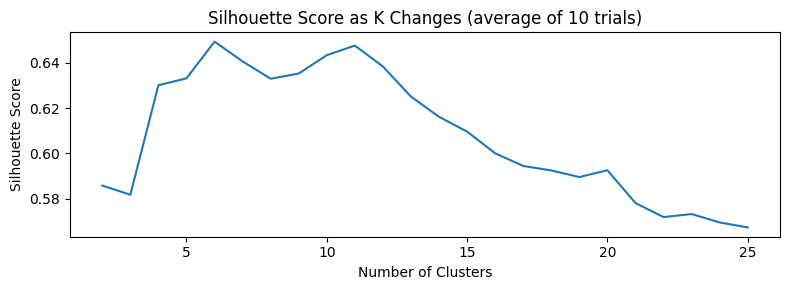

In [11]:
max_k = 25
sil = []
for i in range (2, max_k + 1):
    s = 0
    for j in range(10):
        kmeans = KMeans(n_clusters=i, random_state=j, n_init='auto').fit(taxis[['lon', 'lat']])
        s += silhouette_score(taxis[['lon', 'lat']], kmeans.labels_)
    sil.append(s / 10.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3), tight_layout=True)
ax.plot(range(2, max_k + 1), sil)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score');
ax.set_title('Silhouette Score as K Changes (average of 10 trials)')

Doing this for k-means, even though I've taken the average of 10 runs we see that the plot is no where near as smooth as we've seen the other methods we've looked at. We have clear peaks at $k=6$ and $k=11$. This might seem odd, but you could imagine a situation where we have 6 types of animal in a dataset. Let's say those animals are: aardvark, bird, capybara, diprotodon, elephant, and fennec fox. Five of those classes are fairly specific, but the bird class might actually be comprised of $6$ specific species (maybe african grey parrot, barn owl, crimson rosella, dusky moorhen, eclectus parrot, and fairy wren?). So you could split the data into 6 groups which would match the "high level" set of classes, or go for the set of 11 and capture the more specific groupings.

In the context of this data which concerns cars dropping people off at an airport, we could concieve of larger terminal areas that can be subdivided into regions for specific airlines or similar.

We can do the same thing for a GMM.

Text(0.5, 1.0, 'Silhouette Score as K Changes (average of 10 trials)')

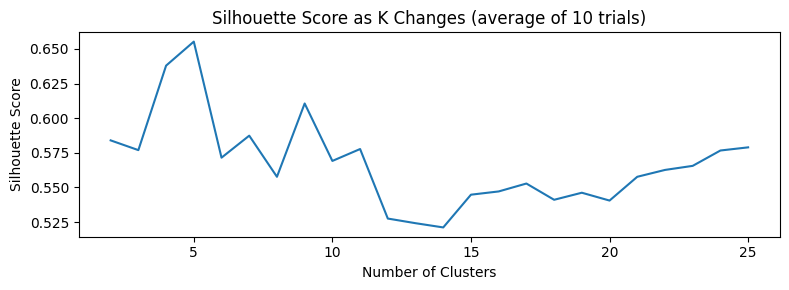

In [12]:
max_k = 25
sil = []
for i in range (2, max_k + 1):
    s = 0
    for j in range(10):
        gmm = GaussianMixture(i, random_state=j).fit(taxis[['lon', 'lat']])
        s += silhouette_score(taxis[['lon', 'lat']], gmm.predict(taxis[['lon', 'lat']]))
    sil.append(s / 10.0)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 3), tight_layout=True)
ax.plot(range(2, max_k + 1), sil)
ax.set_xlabel('Number of Clusters')
ax.set_ylabel('Silhouette Score');
ax.set_title('Silhouette Score as K Changes (average of 10 trials)')

Here, we see a $k=4$ and $k=5$ as being clearly ahead of other options. Interestingly, we get a similar value of $k$ for the GMM as we do with k-means using this approach. This was certainly not the case when using BIC (and it's approximate cousin) which gave us wildly different estimates. The nature of this method, which looks at how well separated clusters are and doesn't consider model complexity (at least not directly) somewhat levels the playing field, though the nature of the GMM does perhaps raise some concerns. 

In particular, a GMM is going to potentially result in some clusters that are bigger and much more spread out than others due to the fact that you learn the cluster covariance alongside the cluster mean. This means that simply using proximity to determine the next best cluster (i.e. $b$ in the silhouette coefficient equation above) is not ideal as this doesn't capture cluster densitiy and is not necessarily reflective of the likelihood of a point belonging to a given cluster (you could address this by using the posteriors to compute something like the silhouette score - but this example is already long enough). As such, in situations where you have data in which the density of samples is inconsistent across the data space, silhouette score could give some misleading results. 

That said, this doesn't mean that you can't use this to help guide selections. Just be mindful that values recommended by any single method are just suggestions. Further visualisations, sanity checks, and common sense are recommended to help guide any selection.

## Final Thoughts

One challenge posed by K-means and GMMs is selecting K. There will be times when you know what K should be in advance. In these cases, using that knowledge is completely appropriate.

Other times, you'll have no clue, and you'll be scratching around for suggested values. There are a lot of metrics and heuristics out there to help guide your choice, and each of these methods may offer different suggestions. As such, when selecting K also keep in mind your application, and be prepared to visualise the clustering results and dive into the data somewhat to understand what is going on. 